In [1]:
import os

os.chdir("/home/jovyan/work")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: /home/jovyan/work


In [2]:
import datetime
import xesmf as xe
import xclim
from xclim import sdba
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import pearsonr

# Reproducibility
np.random.seed(42)

/opt/conda/lib/python3.11/site-packages/xclim/sdba.py:12: UserWarning: The `xclim.sdba` module has been split into its own package `xsdba`. Users are encouraged to use `xsdba` directly. For the time being, `xclim.sdba` will import `xsdba` to allow for API compatibility. This behaviour may change in the future. For more information, see: https://xsdba.readthedocs.io/en/stable/xclim_migration_guide.html
  warnings.warn(


In [3]:
ds = xr.open_dataset("data/era5_indonesia_2018-2022.zarr")

In [4]:
ds

<xarray.Dataset> Size: 4GB
Dimensions:                   (time: 7304, latitude: 181, longitude: 201)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 724B 30.0 29.75 ... -15.0
  * longitude                 (longitude) float32 804B 90.0 90.25 ... 140.0
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 1GB ...
    10m_v_component_of_wind   (time, latitude, longitude) float32 1GB ...
    2m_temperature            (time, latitude, longitude) float32 1GB ...
    total_precipitation_24hr  (time, latitude, longitude) float32 1GB ...

## Cropping data to this dimension
- Low-res shape  : 24 32
- High-res shape : 144 192

In [5]:
import numpy as np
import xarray as xr
import xesmf as xe

# =========================================
# Truth is the constraint — build LR from HR truth
# =========================================
scale = 6

ds_truth = ds.sortby("latitude")  # ensure south → north

tr_lons = ds_truth.longitude.values
tr_lats = ds_truth.latitude.values

# Pseudo-forecast grid from truth stride (Perfect Prognosis setup)
fc_lons = tr_lons[::scale]
fc_lats = tr_lats[::scale]

# ── Force start like forecast-correction notebook ──
lon_start = 90.0
lat_start = -13.5

# Snap to available pseudo-forecast coords
lon_start = float(fc_lons[np.argmin(np.abs(fc_lons - lon_start))])
lat_start = float(fc_lats[np.argmin(np.abs(fc_lats - lat_start))])

# ── Snap to truth grid indices ──
lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))

print(f"lon_start={lon_start}, idx={lon_start_idx}, truth={tr_lons[lon_start_idx]}")
print(f"lat_start={lat_start}, idx={lat_start_idx}, truth={tr_lats[lat_start_idx]}")

# ── Available truth points from start ──
avail_lon = len(tr_lons) - lon_start_idx
avail_lat = len(tr_lats) - lat_start_idx

# ── Max LR points truth can support ──
max_fc_lon = avail_lon // scale
max_fc_lat = avail_lat // scale

# ── Clamp to U-Net friendly size (24×32) ──
max_fc_lon = min(max_fc_lon, 32)
max_fc_lat = min(max_fc_lat, 24)

# ── Slice truth by exact count (HR target) ──
ds_tr = ds_truth.isel(
    longitude=slice(lon_start_idx, lon_start_idx + max_fc_lon * scale),
    latitude=slice(lat_start_idx, lat_start_idx + max_fc_lat * scale),
)
HIGH_LON = len(ds_tr.longitude)
HIGH_LAT = len(ds_tr.latitude)

# ── Build LR grid from HR stride ──
lr_lons = ds_tr.longitude.values[::scale]
lr_lats = ds_tr.latitude.values[::scale]

ds_lr_grid = xr.Dataset(
    coords={
        "lat": ("lat", lr_lats),
        "lon": ("lon", lr_lons),
    }
)

# ── Regrid HR -> LR with xESMF ──
ds_hr_in = ds_tr.rename({"latitude": "lat", "longitude": "lon"})
regridder_hr2lr = xe.Regridder(
    ds_hr_in,
    ds_lr_grid,
    method="bilinear",
    periodic=False,
    reuse_weights=False,
)
ds_fc = regridder_hr2lr(ds_hr_in, keep_attrs=True).rename({"lat": "latitude", "lon": "longitude"})

LOW_LON = len(ds_fc.longitude)
LOW_LAT = len(ds_fc.latitude)

print(f"\nForecast domain : lon {ds_fc.longitude.values[0]:.2f}→{ds_fc.longitude.values[-1]:.2f}"
      f"  lat {ds_fc.latitude.values[0]:.2f}→{ds_fc.latitude.values[-1]:.2f}")
print(f"Truth domain    : lon {ds_tr.longitude.values[0]:.2f}→{ds_tr.longitude.values[-1]:.2f}"
      f"  lat {ds_tr.latitude.values[0]:.2f}→{ds_tr.latitude.values[-1]:.2f}")
print(f"\nFinal forecast grid : {LOW_LAT} lat × {LOW_LON} lon")
print(f"Final truth grid    : {HIGH_LAT} lat × {HIGH_LON} lon")
print(f"Scale lon           : {HIGH_LON / LOW_LON:.6f}")
print(f"Scale lat           : {HIGH_LAT / LOW_LAT:.6f}")

lon_ok = np.allclose(ds_tr.longitude.values[::scale], ds_fc.longitude.values, atol=1e-8)
lat_ok = np.allclose(ds_tr.latitude.values[::scale],  ds_fc.latitude.values,  atol=1e-8)
print(f"Lons aligned        : {lon_ok}")
print(f"Lats aligned        : {lat_ok}")

if HIGH_LON == LOW_LON * scale and HIGH_LAT == LOW_LAT * scale and lon_ok and lat_ok:
    print(f"\n✅ Perfect {scale}× alignment!")
else:
    print(f"\n⚠ Still broken.")

# Keep names expected by your next cells
ds_pp_lr = ds_fc
ds_pp_hr = ds_tr
# ...existing code...

lon_start=90.0, idx=0, truth=90.0
lat_start=-13.5, idx=6, truth=-13.5

Forecast domain : lon 90.00→136.50  lat -13.50→21.00
Truth domain    : lon 90.00→137.75  lat -13.50→22.25

Final forecast grid : 24 lat × 32 lon
Final truth grid    : 144 lat × 192 lon
Scale lon           : 6.000000
Scale lat           : 6.000000
Lons aligned        : True
Lats aligned        : True

✅ Perfect 6× alignment!


In [6]:
ds_pp_lr

<xarray.Dataset> Size: 90MB
Dimensions:                   (time: 7304, latitude: 24, longitude: 32)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 96B -13.5 -12.0 ... 19.5 21.0
  * longitude                 (longitude) float32 128B 90.0 91.5 ... 135.0 136.5
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 22MB -6.866...
    10m_v_component_of_wind   (time, latitude, longitude) float32 22MB 3.512 ...
    2m_temperature            (time, latitude, longitude) float32 22MB 299.5 ...
    total_precipitation_24hr  (time, latitude, longitude) float32 22MB 0.0006...
Attributes:
    regrid_method:  bilinear

In [7]:
ds_pp_hr

<xarray.Dataset> Size: 3GB
Dimensions:                   (time: 7304, latitude: 144, longitude: 192)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 576B -13.5 -13.25 ... 22.25
  * longitude                 (longitude) float32 768B 90.0 90.25 ... 137.8
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 808MB ...
    10m_v_component_of_wind   (time, latitude, longitude) float32 808MB ...
    2m_temperature            (time, latitude, longitude) float32 808MB ...
    total_precipitation_24hr  (time, latitude, longitude) float32 808MB ...

## Check Missing Value

In [8]:
import numpy as np

def check_nan_summary(ds, name):
    print(f"\n==== {name} ====")
    for var in ds.data_vars:
        data = ds[var].values
        total = data.size
        n_nan = np.isnan(data).sum()
        pct = (n_nan / total) * 100
        print(f"{var:30s} | NaNs: {n_nan:10d} | {pct:.5f}%")

check_nan_summary(ds_pp_lr, "Forecast (Low-res)")
check_nan_summary(ds_pp_hr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%

==== Truth (High-res) ====


10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


In [9]:
ds_pred = ds_pp_lr
ds_tar = ds_pp_hr

## Quantile Mapping Downscaling with xclim

In [10]:
# ==========================================
# 1️⃣ Spatial Interpolation (Low-res to High-res)
# ==========================================
# Use bilinear interpolation with proper boundary handling
print("Interpolating low-res to high-res grid with bilinear (boundary-aware)...")

# Create regridder with bilinear method  
# extrap_method='nearest_s2d' handles corners/edges by using nearest neighbor for out-of-bounds points
regridder = xe.Regridder(
    ds_pred, 
    ds_tar, 
    method='bilinear',
    periodic=False,
    extrap_method='nearest_s2d',  # Use nearest neighbor extrapolation at corners/edges
    extrap_num_src_pnts=1,  # Number of source points for extrapolation
)

# Apply regridding to all variables
ds_pred_interp = regridder(ds_pred)
print(f"  → Bilinear interpolation applied to all variables")
print(f"  → Corner/edge handling: nearest neighbor extrapolation")
print(f"Interpolated shape: {ds_pred_interp.dims}")

# ==========================================
# 2️⃣ Train/Val/Test Split (temporal)
# ==========================================
VARS = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "total_precipitation_24hr",
]

N = len(ds_pred_interp.time)
n_train = int(N * 0.7)
n_val   = int(N * 0.15)

# Split indices
train_slice = slice(0, n_train)
val_slice   = slice(n_train, n_train + n_val)
test_slice  = slice(n_train + n_val, None)

print(f"\nSplit sizes (N={N}):")
print(f"  Train : {n_train} ({n_train/N*100:.1f}%)")
print(f"  Val   : {n_val}   ({n_val/N*100:.1f}%)")
print(f"  Test  : {N - n_train - n_val}  ({(N - n_train - n_val)/N*100:.1f}%)")

# Create split datasets
pred_train = ds_pred_interp.isel(time=train_slice)
pred_val   = ds_pred_interp.isel(time=val_slice)
pred_test  = ds_pred_interp.isel(time=test_slice)

tar_train = ds_tar.isel(time=train_slice)
tar_val   = ds_tar.isel(time=val_slice)
tar_test  = ds_tar.isel(time=test_slice)

print("\nDatasets split successfully")

Interpolating low-res to high-res grid with bilinear (boundary-aware)...
  → Bilinear interpolation applied to all variables
  → Corner/edge handling: nearest neighbor extrapolation
Interpolated shape: FrozenMappingWarningOnValuesAccess({'time': 7304, 'latitude': 144, 'longitude': 192})

Split sizes (N=7304):
  Train : 5112 (70.0%)
  Val   : 1095   (15.0%)
  Test  : 1097  (15.0%)

Datasets split successfully


In [11]:
# ==========================================
# Add units metadata for xclim compatibility
# ==========================================
print("\nAdding units metadata...")

# Define units for each variable
units_dict = {
    "10m_u_component_of_wind": "m s-1",
    "10m_v_component_of_wind": "m s-1",
    "2m_temperature": "K",
    "total_precipitation_24hr": "mm",
}

# Add units to all split datasets
for var in VARS:
    pred_train[var].attrs['units'] = units_dict[var]
    pred_val[var].attrs['units'] = units_dict[var]
    pred_test[var].attrs['units'] = units_dict[var]
    
    tar_train[var].attrs['units'] = units_dict[var]
    tar_val[var].attrs['units'] = units_dict[var]
    tar_test[var].attrs['units'] = units_dict[var]
    
    print(f"  {var}: {units_dict[var]}")

print("✓ Units metadata added successfully")


Adding units metadata...
  10m_u_component_of_wind: m s-1
  10m_v_component_of_wind: m s-1
  2m_temperature: K
  total_precipitation_24hr: mm
✓ Units metadata added successfully


In [12]:
# ==========================================
# 3️⃣ Quantile Mapping Training
# ==========================================
print("\n" + "="*60)
print("Training Quantile Mapping models per variable...")
print("="*60)

# Dictionary to store trained QM models
qm_models = {}

for var in VARS:
    print(f"\n[{var}] Training Quantile Mapping...")
    
    # Get training data
    ref_train = tar_train[var]  # Reference (high-res truth)
    hist_train = pred_train[var]  # Historical (interpolated low-res)
    
    # Diagnostic: check unique value count
    ref_values = ref_train.values.flatten()
    hist_values = hist_train.values.flatten()
    ref_values = ref_values[~np.isnan(ref_values)]
    hist_values = hist_values[~np.isnan(hist_values)]
    
    n_unique_ref = len(np.unique(ref_values))
    n_unique_hist = len(np.unique(hist_values))
    print(f"  → Unique values: ref={n_unique_ref}, hist={n_unique_hist}")
    
    # Reduce nquantiles to avoid flat quantile regions
    # Use min of: 20, or half the unique values (safer)
    nquantiles = min(20, min(n_unique_ref, n_unique_hist) // 2)
    nquantiles = max(nquantiles, 5)  # at least 5 quantiles
    
    # For precipitation with many zeros, use even fewer quantiles
    if "precipitation" in var:
        nquantiles = min(10, nquantiles)  # max 10 quantiles for precipitation
        print(f"  → Using {nquantiles} quantiles (reduced for sparse precipitation)")
    else:
        print(f"  → Using {nquantiles} quantiles")
    
    # Use additive adjustment for all variables (more stable than multiplicative)
    print(f"  → Using EmpiricalQuantileMapping (additive adjustment)")
    QM = sdba.EmpiricalQuantileMapping.train(
        ref=ref_train,
        hist=hist_train,
        kind='+',  # additive adjustment - more stable for all variable types
        nquantiles=nquantiles,
    )
    
    qm_models[var] = QM
    print(f"  ✓ Trained with {len(ref_train.time)} timesteps")

print("\n" + "="*60)
print("✓ All Quantile Mapping models trained successfully")
print("="*60)


Training Quantile Mapping models per variable...

_u_component_of_wind] Training Quantile Mapping...
  → Unique values: ref=21766163, hist=67562154
  → Using 20 quantiles
  → Using EmpiricalQuantileMapping (additive adjustment)
  ✓ Trained with 5112 timesteps

_v_component_of_wind] Training Quantile Mapping...
  → Unique values: ref=19197352, hist=70097997
  → Using 20 quantiles
  → Using EmpiricalQuantileMapping (additive adjustment)
  ✓ Trained with 5112 timesteps

_temperature] Training Quantile Mapping...
  → Unique values: ref=957981, hist=863418
  → Using 20 quantiles
  → Using EmpiricalQuantileMapping (additive adjustment)
  ✓ Trained with 5112 timesteps

[total_precipitation_24hr] Training Quantile Mapping...
  → Unique values: ref=21754252, hist=63925268
  → Using 10 quantiles (reduced for sparse precipitation)
  → Using EmpiricalQuantileMapping (additive adjustment)
  ✓ Trained with 5112 timesteps

✓ All Quantile Mapping models trained successfully


In [13]:
# ==========================================
# 4️⃣ Apply Quantile Mapping to Validation Set
# ==========================================
print("\n" + "=" * 60)
print("Applying Quantile Mapping to validation set...")
print("=" * 60)

# Create a new dataset for corrected validation predictions
pred_val_corrected = pred_val.copy(deep=True)

for var in VARS:
    print(f"\n[{var}] Applying QM correction...")

    # Apply the trained QM model (use 'nearest' to avoid interpolation errors)
    corrected = qm_models[var].adjust(pred_val[var], interp="nearest")

    # Ensure corrected data uses the same dim order as pred_val[var]
    if tuple(corrected.dims) != tuple(pred_val[var].dims):
        corrected = corrected.transpose(*pred_val[var].dims)

    # ====== Safeguards against inf/nan ======
    # Get raw values as fallback
    raw_values = pred_val[var].values
    corrected_values = np.array(corrected.values, copy=True)

    # Defensive check for shape mismatch
    if corrected_values.shape != raw_values.shape:
        raise ValueError(
            f"Shape mismatch for {var}: corrected={corrected_values.shape}, raw={raw_values.shape}"
        )

    # Find invalid values (inf or nan)
    invalid_mask = ~np.isfinite(corrected_values)
    n_invalid = int(invalid_mask.sum())

    if n_invalid > 0:
        print(f"  ⚠ WARNING: {n_invalid} invalid values detected, using raw fallback")
        corrected_values = np.where(invalid_mask, raw_values, corrected_values)

    # For precipitation: clip to non-negative
    if "precipitation" in var:
        n_negative = int((corrected_values < 0).sum())
        if n_negative > 0:
            print(f"  ⚠ Clipping {n_negative} negative precipitation values to 0")
        corrected_values = np.maximum(corrected_values, 0.0)

    # Store cleaned values in corrected dataset
    corrected = corrected.copy(data=corrected_values)
    pred_val_corrected[var] = corrected

    print(f"  ✓ Corrected {len(pred_val.time)} timesteps")

print("\n" + "=" * 60)
print("✓ Validation set corrected successfully")
print("=" * 60)


Applying Quantile Mapping to validation set...

_u_component_of_wind] Applying QM correction...
  ✓ Corrected 1095 timesteps

_v_component_of_wind] Applying QM correction...
  ✓ Corrected 1095 timesteps

_temperature] Applying QM correction...
  ✓ Corrected 1095 timesteps

[total_precipitation_24hr] Applying QM correction...
  ⚠ Clipping 1228131 negative precipitation values to 0
  ✓ Corrected 1095 timesteps

✓ Validation set corrected successfully


In [14]:
# ==========================================
# 5️⃣ Evaluation Metrics
# ==========================================
VAR_LABELS = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]

def compute_metrics_xarray(pred_ds, target_ds, var_names, var_labels):
    """
    Compute RMSE, MAE, Bias, Correlation, and ACC per variable.
    pred_ds, target_ds: xarray Datasets
    """
    metrics = {}
    
    for var, label in zip(var_names, var_labels):
        pred = pred_ds[var].values.flatten()
        target = target_ds[var].values.flatten()
        
        # Remove NaN pairs
        mask = ~(np.isnan(pred) | np.isnan(target))
        pred, target = pred[mask], target[mask]
        
        # RMSE
        rmse = np.sqrt(np.mean((pred - target) ** 2))
        
        # MAE
        mae = np.mean(np.abs(pred - target))
        
        # Bias
        bias = np.mean(pred - target)
        
        # Pearson Correlation
        if len(pred) > 1:
            corr = pearsonr(pred, target)[0]
        else:
            corr = 0.0
        
        # ACC — anomaly correlation
        pred_anom = pred - np.mean(pred)
        target_anom = target - np.mean(target)
        num = np.sum(pred_anom * target_anom)
        den = np.sqrt(np.sum(pred_anom ** 2) * np.sum(target_anom ** 2))
        acc = num / (den + 1e-8)
        
        metrics[label] = {
            "RMSE": rmse, "MAE": mae, "Bias": bias,
            "Corr": corr, "ACC": acc,
        }
    
    return metrics


def print_metrics(metrics, prefix=""):
    header = f"{'Variable':<18} {'RMSE':>8} {'MAE':>8} {'Bias':>8} {'Corr':>8} {'ACC':>8}"
    print(f"\n{prefix}")
    print(header)
    print("-" * len(header))
    for var, m in metrics.items():
        print(f"{var:<18} {m['RMSE']:>8.4f} {m['MAE']:>8.4f} {m['Bias']:>+8.4f} {m['Corr']:>8.4f} {m['ACC']:>8.4f}")

In [15]:
# ==========================================
# 6️⃣ Evaluate on Validation Set
# ==========================================
print("\n" + "="*60)
print("Validation Set Evaluation")
print("="*60)

# Compare raw interpolated vs QM-corrected vs truth
metrics_raw = compute_metrics_xarray(pred_val, tar_val, VARS, VAR_LABELS)
metrics_qm = compute_metrics_xarray(pred_val_corrected, tar_val, VARS, VAR_LABELS)

print_metrics(metrics_raw, prefix="📊 Validation - Raw Bilinear Interpolation")
print_metrics(metrics_qm, prefix="📊 Validation - Quantile Mapping Corrected")


Validation Set Evaluation

📊 Validation - Raw Bilinear Interpolation
Variable               RMSE      MAE     Bias     Corr      ACC
---------------------------------------------------------------
U10 (m/s)            0.8621   0.5331  -0.0122   0.9785   0.9785
V10 (m/s)            0.7961   0.5035  -0.0116   0.9725   0.9726
T2m (K)              0.9548   0.4978  +0.0204   0.9169   0.9170
TP 24hr (mm)         0.0054   0.0022  +0.0000   0.8854   0.8851

📊 Validation - Quantile Mapping Corrected
Variable               RMSE      MAE     Bias     Corr      ACC
---------------------------------------------------------------
U10 (m/s)            0.6772   0.4319  +0.0028   0.9868   0.9869
V10 (m/s)            0.6688   0.4285  -0.0160   0.9808   0.9809
T2m (K)              0.5376   0.3192  -0.0053   0.9746   0.9746
TP 24hr (mm)         0.0053   0.0021  -0.0001   0.8897   0.8900


In [16]:
# ==========================================
# 7️⃣ Apply Quantile Mapping to Test Set
# ==========================================
print("\n" + "="*60)
print("Applying Quantile Mapping to test set...")
print("="*60)

# Create a new dataset for corrected test predictions
pred_test_corrected = pred_test.copy(deep=True)

for var in VARS:
    print(f"\n[{var}] Applying QM correction to test set...")
    
    # Apply the trained QM model (use 'nearest' to avoid interpolation errors)
    corrected = qm_models[var].adjust(pred_test[var], interp='nearest')
    
    # Ensure corrected data uses the same dim order as pred_test[var]
    if tuple(corrected.dims) != tuple(pred_test[var].dims):
        corrected = corrected.transpose(*pred_test[var].dims)
    
    # ====== Safeguards against inf/nan ======
    # Get raw values as fallback
    raw_values = pred_test[var].values
    corrected_values = np.array(corrected.values, copy=True)
    
    # Defensive check for shape mismatch
    if corrected_values.shape != raw_values.shape:
        raise ValueError(
            f"Shape mismatch for {var}: corrected={corrected_values.shape}, raw={raw_values.shape}"
        )
    
    # Find invalid values (inf or nan)
    invalid_mask = ~np.isfinite(corrected_values)
    n_invalid = int(invalid_mask.sum())
    
    if n_invalid > 0:
        print(f"  ⚠ WARNING: {n_invalid} invalid values detected, using raw fallback")
        corrected_values = np.where(invalid_mask, raw_values, corrected_values)
    
    # For precipitation: clip to non-negative
    if "precipitation" in var:
        n_negative = int((corrected_values < 0).sum())
        if n_negative > 0:
            print(f"  ⚠ Clipping {n_negative} negative precipitation values to 0")
        corrected_values = np.maximum(corrected_values, 0.0)
    
    # Store cleaned values in corrected dataset
    corrected = corrected.copy(data=corrected_values)
    pred_test_corrected[var] = corrected
    
    print(f"  ✓ Corrected {len(pred_test.time)} timesteps")

print("\n" + "="*60)
print("✓ Test set corrected successfully")
print("="*60)


Applying Quantile Mapping to test set...

_u_component_of_wind] Applying QM correction to test set...
  ✓ Corrected 1097 timesteps

_v_component_of_wind] Applying QM correction to test set...
  ✓ Corrected 1097 timesteps

_temperature] Applying QM correction to test set...
  ✓ Corrected 1097 timesteps

[total_precipitation_24hr] Applying QM correction to test set...
  ⚠ Clipping 985065 negative precipitation values to 0
  ✓ Corrected 1097 timesteps

✓ Test set corrected successfully


In [17]:
# ==========================================
# 8️⃣ Test Set Evaluation
# ==========================================
print("\n" + "="*60)
print("Test Set Evaluation")
print("="*60)

# Compare raw interpolated vs QM-corrected vs truth
metrics_test_raw = compute_metrics_xarray(pred_test, tar_test, VARS, VAR_LABELS)
metrics_test_qm = compute_metrics_xarray(pred_test_corrected, tar_test, VARS, VAR_LABELS)

print_metrics(metrics_test_raw, prefix="📊 Test - Raw Bilinear Interpolation")
print_metrics(metrics_test_qm, prefix="📊 Test - Quantile Mapping Corrected")


Test Set Evaluation

📊 Test - Raw Bilinear Interpolation
Variable               RMSE      MAE     Bias     Corr      ACC
---------------------------------------------------------------
U10 (m/s)            0.8209   0.5140  -0.0153   0.9772   0.9773
V10 (m/s)            0.7670   0.4886  -0.0029   0.9698   0.9698
T2m (K)              0.9434   0.4950  +0.0161   0.8947   0.8948
TP 24hr (mm)         0.0055   0.0023  +0.0000   0.8813   0.8812

📊 Test - Quantile Mapping Corrected
Variable               RMSE      MAE     Bias     Corr      ACC
---------------------------------------------------------------
U10 (m/s)            0.6635   0.4275  +0.0111   0.9852   0.9853
V10 (m/s)            0.6527   0.4231  +0.0106   0.9783   0.9783
T2m (K)              0.5327   0.3200  +0.0024   0.9680   0.9680
TP 24hr (mm)         0.0053   0.0022  -0.0001   0.8868   0.8866


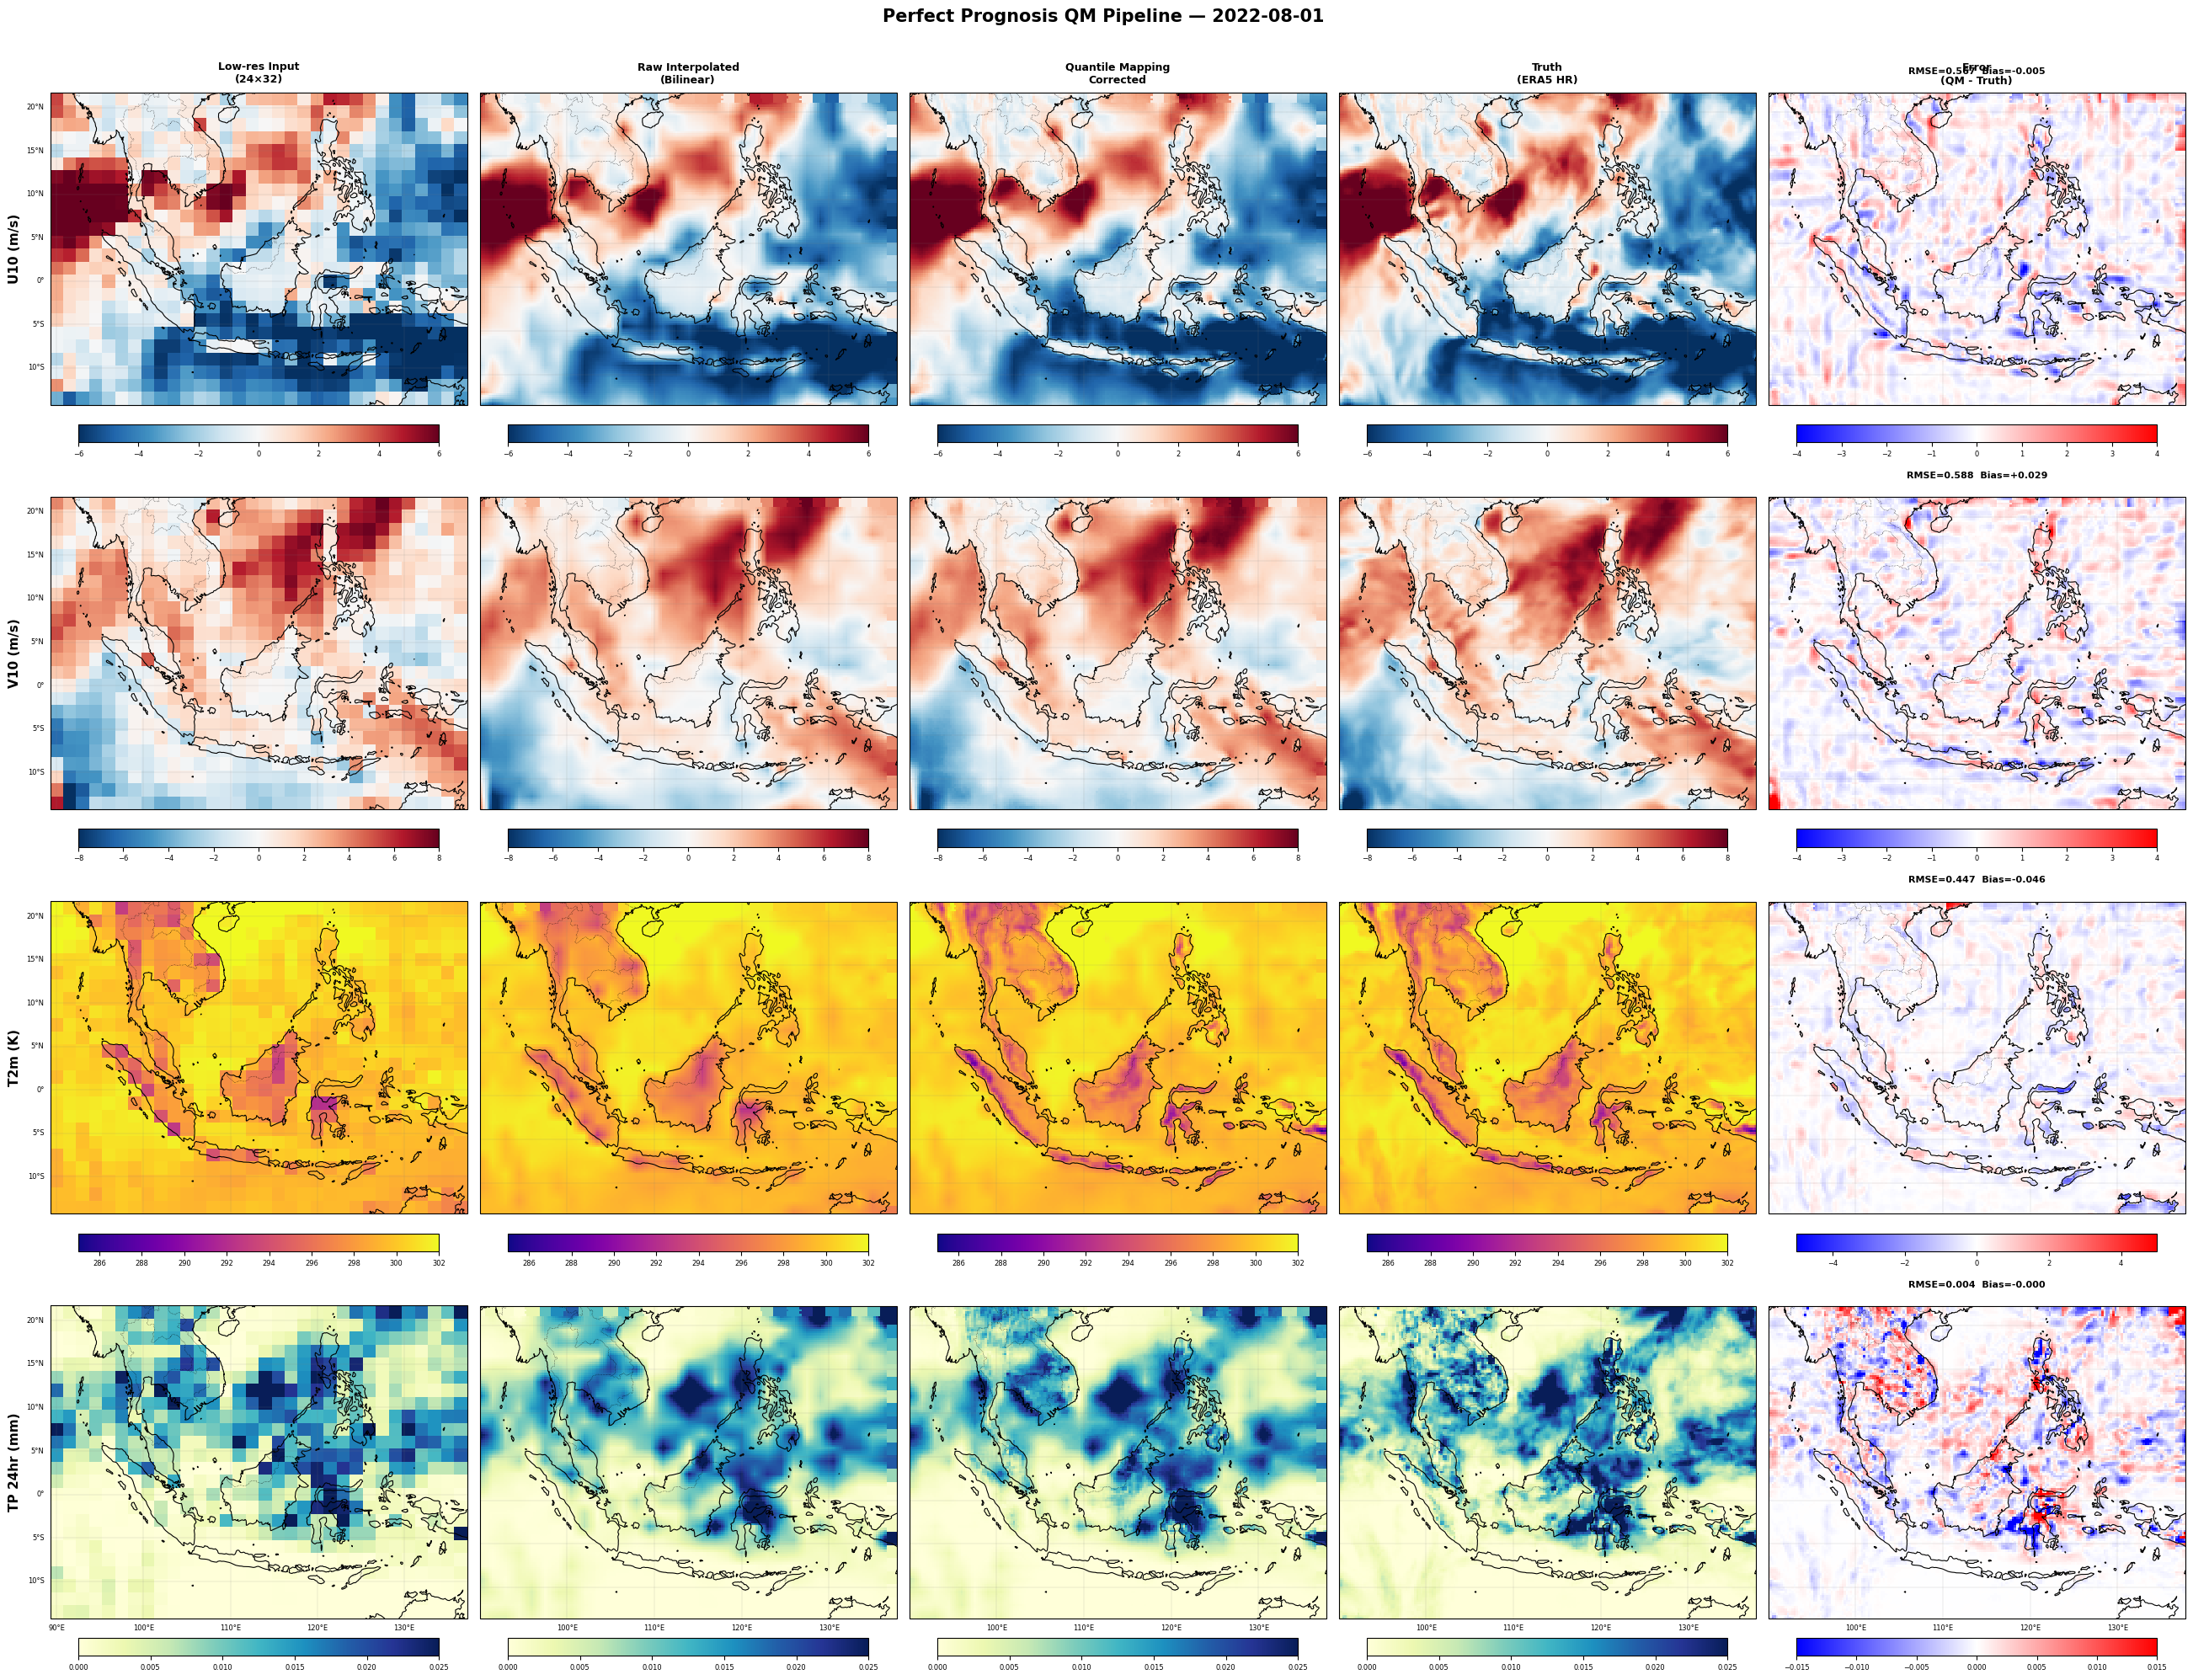


📊 Visualization shows full pipeline:
   Low-res ERA5 → Bilinear Interp → Quantile Mapping → High-res ERA5 Truth → Error


In [18]:
# ==========================================
# 🔟 Spatial Visualization - Sample Date
# ==========================================
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Config
VAR_LABELS_VIZ = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]
target_date = np.datetime64("2022-08-01")

# Hardcoded color ranges (adjusted based on data)
#                   U10    V10    T2m       TP
FIELD_VMIN = [      -6,    -8,   285,   0.000]
FIELD_VMAX = [       6,     8,   302,   0.025]
ERROR_LIM  = [       4,     4,     5,   0.015]

# ==============================
# Find sample in test set
# ==============================
test_times = pred_test.time.values
idx = np.where(test_times == target_date)[0]
if len(idx) == 0:
    print(f"⚠ {target_date} not found in test set.")
    print(f"Available range: {test_times[0]} → {test_times[-1]}")
    # Use first test sample instead
    idx = 0
    target_date = test_times[0]
    print(f"Using first test date: {target_date}")
else:
    idx = idx[0]

# Get sample data (high-res)
pred_raw_sample = pred_test.isel(time=idx)
pred_qm_sample = pred_test_corrected.isel(time=idx)
truth_sample = tar_test.isel(time=idx)

# Get low-res input (before interpolation)
# Find corresponding time in ds_pred
lowres_idx = np.where(ds_pred.time.values == truth_sample.time.values)[0]
if len(lowres_idx) > 0:
    lowres_sample = ds_pred.isel(time=lowres_idx[0])
else:
    lowres_sample = ds_pred.isel(time=0)

# Get coordinates
lons_hr = truth_sample.longitude.values
lats_hr = truth_sample.latitude.values
lons_lr = lowres_sample.longitude.values
lats_lr = lowres_sample.latitude.values

# Set extent for all maps
extent = [lons_hr.min(), lons_hr.max(), lats_hr.min(), lats_hr.max()]

# ==============================
# Plot: 4 rows × 5 cols
# cols: Low-res Input | Raw Interpolated | QM Corrected | Truth | Error
# ==============================
proj = ccrs.PlateCarree()
n_vars = len(VARS)

col_titles = [
    f"Low-res Input\n({len(lats_lr)}×{len(lons_lr)})",
    "Raw Interpolated\n(Bilinear)",
    "Quantile Mapping\nCorrected",
    "Truth\n(ERA5 HR)",
    "Error\n(QM - Truth)",
]

cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

fig, axes = plt.subplots(
    n_vars, 5,
    figsize=(26, 5 * n_vars),
    subplot_kw={"projection": proj},
)

# Helper function to ensure correct shape
def ensure_shape(data, target_shape):
    """Ensure data is in (lat, lon) shape"""
    if data.shape != target_shape:
        return data.T
    return data

target_shape_hr = (len(lats_hr), len(lons_hr))
target_shape_lr = (len(lats_lr), len(lons_lr))

for v_idx, var in enumerate(VARS):
    # Get low-res data
    lowres_v = ensure_shape(lowres_sample[var].values, target_shape_lr)
    
    # Get high-res data (convert DataArray to numpy) and ensure consistent shape
    raw_v = ensure_shape(pred_raw_sample[var].values, target_shape_hr)
    qm_v = ensure_shape(pred_qm_sample[var].values, target_shape_hr)
    true_v = ensure_shape(truth_sample[var].values, target_shape_hr)
    
    # Now compute error (shapes are guaranteed to match)
    err_v = qm_v - true_v
    
    cmap_f = cmaps_field[v_idx]
    
    # Hardcoded ranges
    vmin = FIELD_VMIN[v_idx]
    vmax = FIELD_VMAX[v_idx]
    elim = ERROR_LIM[v_idx]
    
    panels = [
        (lowres_v, lons_lr, lats_lr, cmap_f, vmin,  vmax, False),  # Low-res
        (raw_v,    lons_hr, lats_hr, cmap_f, vmin,  vmax, True),   # Raw interp
        (qm_v,     lons_hr, lats_hr, cmap_f, vmin,  vmax, True),   # QM
        (true_v,   lons_hr, lats_hr, cmap_f, vmin,  vmax, True),   # Truth
        (err_v,    lons_hr, lats_hr, "bwr",  -elim,  elim, True),  # Error
    ]
    
    for col, (data, lons, lats, cmap, lo, hi, is_highres) in enumerate(panels):
        ax = axes[v_idx, col]
        
        # Set extent to prevent padding issues
        if is_highres:
            ax.set_extent(extent, crs=proj)
        
        im = ax.pcolormesh(
            lons, lats, data,
            cmap=cmap, vmin=lo, vmax=hi,
            shading="nearest",
            transform=proj,
        )
        
        # Add features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":", zorder=2)
        ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0, alpha=0.3)
        ax.add_feature(cfeature.OCEAN, facecolor="lightcyan", zorder=0, alpha=0.3)
        
        # Gridlines with reduced clutter
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4,
                         x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 6}
        gl.ylabel_style = {"size": 6}
        
        # Only show labels on left and bottom edges
        if col > 0:
            gl.left_labels = False
        if v_idx < n_vars - 1:
            gl.bottom_labels = False
        
        # Colorbar
        cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.046, shrink=0.9)
        cb.ax.tick_params(labelsize=6)
        
        # Titles
        if v_idx == 0:
            ax.set_title(col_titles[col], fontsize=9, fontweight="bold", pad=8)
        
        if col == 0:
            ax.text(-0.10, 0.5, VAR_LABELS_VIZ[v_idx], transform=ax.transAxes,
                    fontsize=11, fontweight="bold", va="center", rotation=90)
    
    # RMSE + bias on error panel
    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    axes[v_idx, 4].text(0.5, 1.06, f"RMSE={rmse:.3f}  Bias={bias:+.3f}",
                        transform=axes[v_idx, 4].transAxes,
                        ha='center', fontsize=8, fontweight='bold')

fig.suptitle(
    f"Perfect Prognosis QM Pipeline — {str(target_date)[:10]}",
    fontsize=15, fontweight="bold", y=0.995,
)
plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.savefig(f"pp_qm_pipeline_{str(target_date)[:10]}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📊 Visualization shows full pipeline:")
print(f"   Low-res ERA5 → Bilinear Interp → Quantile Mapping → High-res ERA5 Truth → Error")

In [20]:
# ==========================================
# Diagnostic: Investigate QM Performance
# ==========================================
print("\n" + "="*70)
print("Diagnostic Analysis - Why is QM performing poorly on some variables?")
print("="*70)

for var, label in zip(VARS, VAR_LABELS):
    print(f"\n{'='*70}")
    print(f"Variable: {label}")
    print(f"{'='*70}")
    
    # Get test data
    pred_raw = pred_test[var].values.flatten()
    pred_qm = pred_test_corrected[var].values.flatten()
    truth = tar_test[var].values.flatten()
    
    # Remove NaNs
    mask = ~(np.isnan(pred_raw) | np.isnan(pred_qm) | np.isnan(truth))
    pred_raw = pred_raw[mask]
    pred_qm = pred_qm[mask]
    truth = truth[mask]
    
    # Statistics
    print(f"\nData range:")
    print(f"  Truth:      min={truth.min():.4f}, max={truth.max():.4f}, mean={truth.mean():.4f}, std={truth.std():.4f}")
    print(f"  Raw interp: min={pred_raw.min():.4f}, max={pred_raw.max():.4f}, mean={pred_raw.mean():.4f}, std={pred_raw.std():.4f}")
    print(f"  QM correc:  min={pred_qm.min():.4f}, max={pred_qm.max():.4f}, mean={pred_qm.mean():.4f}, std={pred_qm.std():.4f}")
    
    # Errors
    err_raw = pred_raw - truth
    err_qm = pred_qm - truth
    
    print(f"\nError statistics:")
    print(f"  Raw bias:  {err_raw.mean():+.4f}")
    print(f"  QM bias:   {err_qm.mean():+.4f}")
    print(f"  Raw RMSE:  {np.sqrt((err_raw**2).mean()):.4f}")
    print(f"  QM RMSE:   {np.sqrt((err_qm**2).mean()):.4f}")
    print(f"  Raw MAE:   {np.abs(err_raw).mean():.4f}")
    print(f"  QM MAE:    {np.abs(err_qm).mean():.4f}")
    
    # Check for extreme values
    extreme_qm = np.sum(np.abs(pred_qm) > 1e6)
    extreme_raw = np.sum(np.abs(pred_raw) > 1e6)
    if extreme_qm > 0 or extreme_raw > 0:
        print(f"\n⚠ WARNING: Extreme values detected!")
        print(f"  Raw: {extreme_raw} values > 1e6")
        print(f"  QM:  {extreme_qm} values > 1e6")

print("\n" + "="*70)


Diagnostic Analysis - Why is QM performing poorly on some variables?

Variable: U10 (m/s)

Data range:
  Truth:      min=-24.0173, max=23.6283, mean=-1.0147, std=3.8706
  Raw interp: min=-20.4160, max=20.4332, mean=-1.0300, std=3.7608
  QM correc:  min=-20.4160, max=21.1366, mean=-1.0036, std=3.8557

Error statistics:
  Raw bias:  -0.0153
  QM bias:   +0.0111
  Raw RMSE:  0.8209
  QM RMSE:   0.6635
  Raw MAE:   0.5140
  QM MAE:    0.4275

Variable: V10 (m/s)

Data range:
  Truth:      min=-26.0876, max=26.1467, mean=0.6536, std=3.1453
  Raw interp: min=-24.5452, max=22.6857, mean=0.6506, std=3.0316
  QM correc:  min=-24.5452, max=23.3626, mean=0.6641, std=3.1211

Error statistics:
  Raw bias:  -0.0029
  QM bias:   +0.0106
  Raw RMSE:  0.7670
  QM RMSE:   0.6527
  Raw MAE:   0.4886
  QM MAE:    0.4231

Variable: T2m (K)

Data range:
  Truth:      min=275.5442, max=314.8869, mean=300.1446, std=2.1124
  Raw interp: min=277.4778, max=314.0026, mean=300.1608, std=1.8920
  QM correc:  min=2

In [22]:
# ==========================================
# 1️⃣1️⃣ Aggregate Test Set Evaluation with Skill Scores
# ==========================================
from scipy.stats import pearsonr

print("\n" + "="*100)
print(f"{'Variable':<18} | {'RMSE':>8} | {'MAE':>8} | {'Bias':>8} | {'Corr':>8} | {'Baseline RMSE':>14} | {'Skill':>8}")
print("="*100)

for v_idx, var in enumerate(VARS):
    # QM corrected predictions
    pred_qm = pred_test_corrected[var].values.flatten()
    
    # Truth
    true_v = tar_test[var].values.flatten()
    
    # Baseline (raw bilinear interpolation)
    baseline_v = pred_test[var].values.flatten()
    
    # Remove NaN pairs
    mask = ~(np.isnan(pred_qm) | np.isnan(true_v) | np.isnan(baseline_v))
    pred_qm, true_v, baseline_v = pred_qm[mask], true_v[mask], baseline_v[mask]
    
    # QM metrics
    rmse = np.sqrt(np.mean((pred_qm - true_v) ** 2))
    mae = np.mean(np.abs(pred_qm - true_v))
    bias = np.mean(pred_qm - true_v)
    corr = pearsonr(pred_qm, true_v)[0] if len(pred_qm) > 1 else 0.0
    
    # Baseline RMSE
    rmse_base = np.sqrt(np.mean((baseline_v - true_v) ** 2))
    
    # Skill score: 1 - (RMSE_QM / RMSE_baseline)
    skill = 1.0 - (rmse / rmse_base) if rmse_base > 0 else 0.0
    
    label = VAR_LABELS[v_idx]
    print(f"{label:<18} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

print("="*100)
print("\n✓ Skill > 0 means Quantile Mapping improves over raw bilinear interpolation.")
print("✓ Skill = 1 would mean perfect correction (RMSE = 0).")


Variable           |     RMSE |      MAE |     Bias |     Corr |  Baseline RMSE |    Skill
U10 (m/s)          |   0.6635 |   0.4275 |  +0.0111 |   0.9852 |         0.8209 |  +0.1918
V10 (m/s)          |   0.6527 |   0.4231 |  +0.0106 |   0.9783 |         0.7670 |  +0.1490
T2m (K)            |   0.5327 |   0.3200 |  +0.0024 |   0.9680 |         0.9434 |  +0.4353
TP 24hr (mm)       |   0.0053 |   0.0022 |  -0.0001 |   0.8868 |         0.0055 |  +0.0189

✓ Skill > 0 means Quantile Mapping improves over raw bilinear interpolation.
✓ Skill = 1 would mean perfect correction (RMSE = 0).
